<a href="https://www.kaggle.com/code/sonawanelalitsunil/deepseek-vs-chatgpt-ai-platform-ml-100?scriptVersionId=227154080" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/deepseek-vs-chatgpt-ai-platform-comparison/LICENSE
/kaggle/input/deepseek-vs-chatgpt-ai-platform-comparison/README.md
/kaggle/input/deepseek-vs-chatgpt-ai-platform-comparison/deepseek_vs_chatgpt.csv


## DeepSeek vs. ChatGPT: AI Platform Showdown

**AI-driven conversational platforms like DeepSeek and ChatGPT are transforming industries by enabling human-like interactions, problem-solving, and content generation. While both leverage deep learning, they have distinct features, architectures, and applications.**

1. Model Architecture & Capabilities
   
ChatGPT (by OpenAI):

Built on GPT-4, a state-of-the-art transformer model trained with extensive reinforcement learning from human feedback (RLHF).
Excels in long-form reasoning, contextual understanding, and nuanced responses across various domains.
Offers multimodal support (text, images, and code execution), making it highly versatile.
Available in different versions (GPT-4 Turbo, GPT-3.5) to balance cost and performance.

DeepSeek:

An open-source large language model (LLM) optimized for Chinese and English languages.
Uses a Mixture of Experts (MoE) architecture, which selectively activates model parameters to optimize efficiency.
Targets low-latency and cost-efficient inference while maintaining strong generative capabilities.
Prioritizes scientific and technical applications, making it useful for coding and academic research.


2. Performance & Use Cases
   
ChatGPT:

Best for general-purpose conversations, creative writing, customer support, and knowledge-intensive applications.
Widely integrated into enterprise solutions, coding assistants (Code Interpreter), and productivity tools (Microsoft Copilot, Notion AI, etc.).
Offers APIs for developers and business applications.

DeepSeek:

Optimized for technical and research-oriented use cases with a focus on STEM applications, coding, and multilingual processing.
More suited for open-source AI projects where customization and adaptability matter.
Used in AI research and engineering teams looking for an efficient, scalable model for specific workloads.


3. Pricing & Accessibility

ChatGPT:

Freemium model:
Free-tier access to GPT-3.5.
GPT-4 Turbo available via ChatGPT Plus ($20/month).
Enterprise options for businesses with customized AI solutions.

DeepSeek:
Free and open-source, allowing customization and self-hosting.
No official pricing, but requires compute resources for self-deployment.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/deepseek-vs-chatgpt-ai-platform-comparison/deepseek_vs_chatgpt.csv')

In [3]:
df.head()

,Date,Month_Num,Weekday,AI_Platform,AI_Model_Version,Active_Users,New_Users,Churned_Users,Daily_Churn_Rate,Retention_Rate,...,Session_Duration_sec,Device_Type,Language,Response_Accuracy,Response_Speed_sec,Response_Time_Category,Correction_Needed,User_Return_Frequency,Customer_Support_Interactions,Region
0,2024-09-21,9,Saturday,ChatGPT,GPT-4-turbo,500000,25000,25000,0.05,0.95,...,40,Mobile,es,0.7842,3.30,Standard,0,6,2,Antarctica (the territory South of 60 deg S)
1,2024-09-21,9,Saturday,ChatGPT,GPT-4-turbo,500000,25000,25000,0.05,0.95,...,24,Laptop/Desktop,zh,0.8194,3.28,Standard,1,2,2,Ukraine
2,2024-09-21,9,Saturday,ChatGPT,GPT-4-turbo,500000,25000,25000,0.05,0.95,...,34,Mobile,en,0.8090,3.07,Standard,0,2,0,Grenada
3,2024-09-21,9,Saturday,ChatGPT,GPT-4-turbo,500000,25000,25000,0.05,0.95,...,18,Mobile,fr,0.8233,3.06,Standard,0,9,0,Guyana
4,2024-05-16,5,Thursday,DeepSeek,DeepSeek-Chat 1.5,1700000,170000,34000,0.02,0.95,...,10,Mobile,de,0.9366,1.48,Fast,0,9,3,India


In [4]:
df.tail()

,Date,Month_Num,Weekday,AI_Platform,AI_Model_Version,Active_Users,New_Users,Churned_Users,Daily_Churn_Rate,Retention_Rate,...,Session_Duration_sec,Device_Type,Language,Response_Accuracy,Response_Speed_sec,Response_Time_Category,Correction_Needed,User_Return_Frequency,Customer_Support_Interactions,Region
9995,2024-05-17,5,Friday,DeepSeek,DeepSeek-Chat 1.5,1700000,170000,34000,0.02,0.95,...,34,Laptop/Desktop,zh,0.9791,0.60,Instant,0,7,2,Seychelles
9996,2024-05-17,5,Friday,DeepSeek,DeepSeek-Chat 1.5,1700000,170000,34000,0.02,0.95,...,19,Laptop/Desktop,en,0.9132,0.83,Instant,0,5,0,Christmas Island
9997,2024-05-17,5,Friday,DeepSeek,DeepSeek-Chat 1.5,1700000,170000,34000,0.02,0.95,...,29,Laptop/Desktop,de,0.9516,0.94,Instant,0,10,2,Ethiopia
9998,2024-05-17,5,Friday,DeepSeek,DeepSeek-Chat 1.5,1700000,170000,34000,0.02,0.95,...,21,Mobile,de,0.9359,0.83,Instant,0,5,3,Puerto Rico
9999,2024-05-17,5,Friday,DeepSeek,DeepSeek-Chat 1.5,1700000,170000,34000,0.02,0.95,...,58,Mobile,fr,0.9399,0.76,Instant,1,7,1,Kyrgyz Republic


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date                           10000 non-null  object 
 1   Month_Num                      10000 non-null  int64  
 2   Weekday                        10000 non-null  object 
 3   AI_Platform                    10000 non-null  object 
 4   AI_Model_Version               10000 non-null  object 
 5   Active_Users                   10000 non-null  int64  
 6   New_Users                      10000 non-null  int64  
 7   Churned_Users                  10000 non-null  int64  
 8   Daily_Churn_Rate               10000 non-null  float64
 9   Retention_Rate                 10000 non-null  float64
 10  User_ID                        10000 non-null  object 
 11  Query_Type                     10000 non-null  object 
 12  Input_Text                     10000 non-null  

In [6]:
df.dtypes

Date                              object
Month_Num                          int64
Weekday                           object
AI_Platform                       object
AI_Model_Version                  object
Active_Users                       int64
New_Users                          int64
Churned_Users                      int64
Daily_Churn_Rate                 float64
Retention_Rate                   float64
User_ID                           object
Query_Type                        object
Input_Text                        object
Input_Text_Length                  int64
Response_Tokens                    int64
Topic_Category                    object
User_Rating                        int64
User_Experience_Score            float64
Session_Duration_sec               int64
Device_Type                       object
Language                          object
Response_Accuracy                float64
Response_Speed_sec               float64
Response_Time_Category            object
Correction_Neede

In [7]:
df.corr

<bound method DataFrame.corr of             Date  Month_Num   Weekday AI_Platform   AI_Model_Version  \
0     2024-09-21          9  Saturday     ChatGPT        GPT-4-turbo   
1     2024-09-21          9  Saturday     ChatGPT        GPT-4-turbo   
2     2024-09-21          9  Saturday     ChatGPT        GPT-4-turbo   
3     2024-09-21          9  Saturday     ChatGPT        GPT-4-turbo   
4     2024-05-16          5  Thursday    DeepSeek  DeepSeek-Chat 1.5   
...          ...        ...       ...         ...                ...   
9995  2024-05-17          5    Friday    DeepSeek  DeepSeek-Chat 1.5   
9996  2024-05-17          5    Friday    DeepSeek  DeepSeek-Chat 1.5   
9997  2024-05-17          5    Friday    DeepSeek  DeepSeek-Chat 1.5   
9998  2024-05-17          5    Friday    DeepSeek  DeepSeek-Chat 1.5   
9999  2024-05-17          5    Friday    DeepSeek  DeepSeek-Chat 1.5   

      Active_Users  New_Users  Churned_Users  Daily_Churn_Rate  \
0           500000      25000        

In [8]:
df.isnull().sum()

Date                               0
Month_Num                          0
Weekday                            0
AI_Platform                        0
AI_Model_Version                   0
Active_Users                       0
New_Users                          0
Churned_Users                      0
Daily_Churn_Rate                   0
Retention_Rate                     0
User_ID                            0
Query_Type                         0
Input_Text                         0
Input_Text_Length                  0
Response_Tokens                    0
Topic_Category                     0
User_Rating                        0
User_Experience_Score              0
Session_Duration_sec               0
Device_Type                        0
Language                           0
Response_Accuracy                379
Response_Speed_sec                 0
Response_Time_Category             0
Correction_Needed                  0
User_Return_Frequency              0
Customer_Support_Interactions      0
R

In [9]:
df.duplicated().sum()

0

In [10]:
df.drop('Response_Accuracy', axis=1, inplace=True)


In [11]:
df.isnull().sum()

Date                             0
Month_Num                        0
Weekday                          0
AI_Platform                      0
AI_Model_Version                 0
Active_Users                     0
New_Users                        0
Churned_Users                    0
Daily_Churn_Rate                 0
Retention_Rate                   0
User_ID                          0
Query_Type                       0
Input_Text                       0
Input_Text_Length                0
Response_Tokens                  0
Topic_Category                   0
User_Rating                      0
User_Experience_Score            0
Session_Duration_sec             0
Device_Type                      0
Language                         0
Response_Speed_sec               0
Response_Time_Category           0
Correction_Needed                0
User_Return_Frequency            0
Customer_Support_Interactions    0
Region                           0
dtype: int64

In [12]:
df.columns

Index(['Date', 'Month_Num', 'Weekday', 'AI_Platform', 'AI_Model_Version',
       'Active_Users', 'New_Users', 'Churned_Users', 'Daily_Churn_Rate',
       'Retention_Rate', 'User_ID', 'Query_Type', 'Input_Text',
       'Input_Text_Length', 'Response_Tokens', 'Topic_Category', 'User_Rating',
       'User_Experience_Score', 'Session_Duration_sec', 'Device_Type',
       'Language', 'Response_Speed_sec', 'Response_Time_Category',
       'Correction_Needed', 'User_Return_Frequency',
       'Customer_Support_Interactions', 'Region'],
      dtype='object')

## Data visualizations

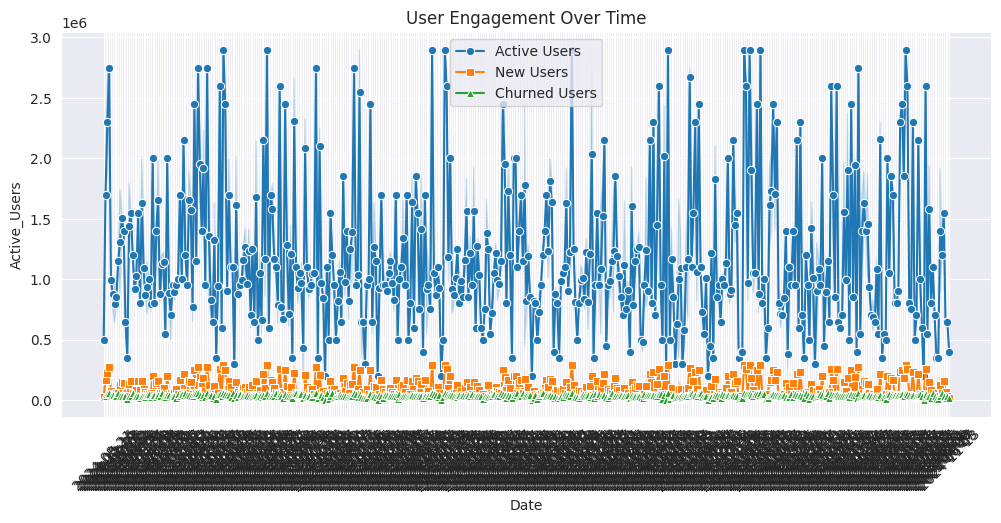

In [13]:
sns.set_style("darkgrid")

# 1. Trend of Active Users Over Time
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='Date', y='Active_Users', label='Active Users', marker='o')
sns.lineplot(data=df, x='Date', y='New_Users', label='New Users', marker='s')
sns.lineplot(data=df, x='Date', y='Churned_Users', label='Churned Users', marker='^')
plt.xticks(rotation=45)
plt.title("User Engagement Over Time")
plt.legend()
plt.show()

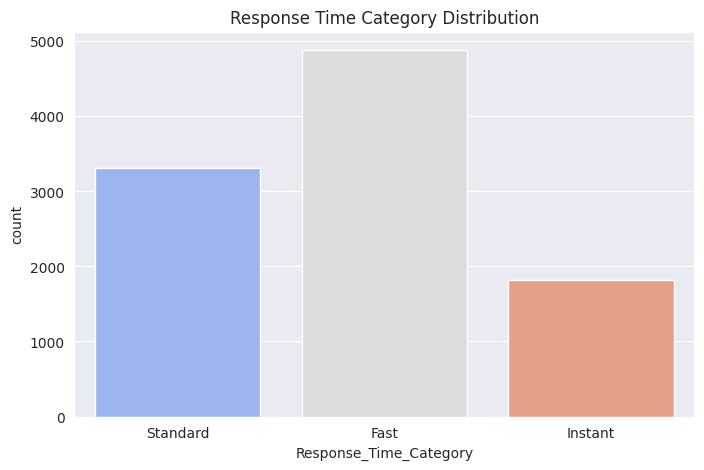

In [14]:
# 2. Distribution of Response Speed Categories
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Response_Time_Category', palette='coolwarm')
plt.title("Response Time Category Distribution")
plt.show()

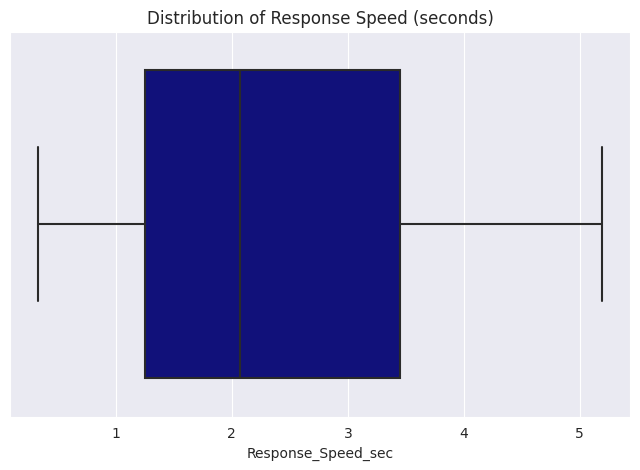

In [15]:
# 3. Boxplot of Response Speed
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Response_Speed_sec', color='darkblue')
plt.title("Distribution of Response Speed (seconds)")
plt.show()

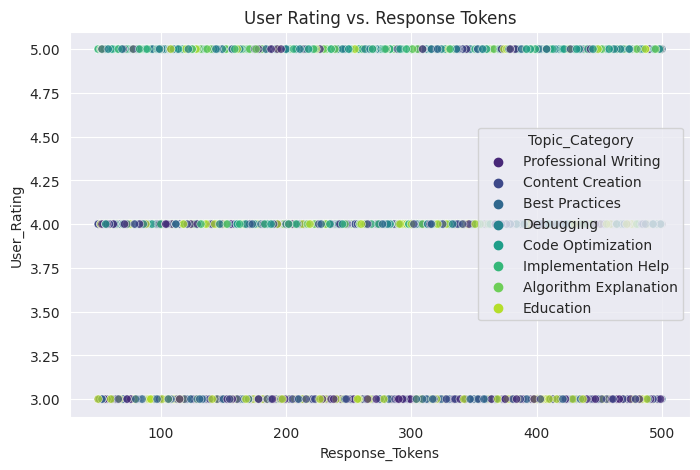

In [16]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Response_Tokens', y='User_Rating', hue='Topic_Category', palette='viridis', alpha=0.7)
plt.title("User Rating vs. Response Tokens")
plt.show()

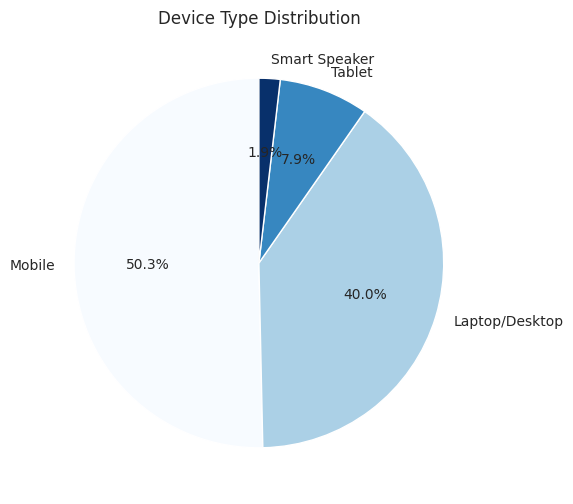

In [17]:
# 5. Pie Chart for Device Type Usage
plt.figure(figsize=(6, 6))
df['Device_Type'].value_counts().plot.pie(autopct='%1.1f%%', cmap='Blues', startangle=90)
plt.title("Device Type Distribution")
plt.ylabel('')
plt.show()

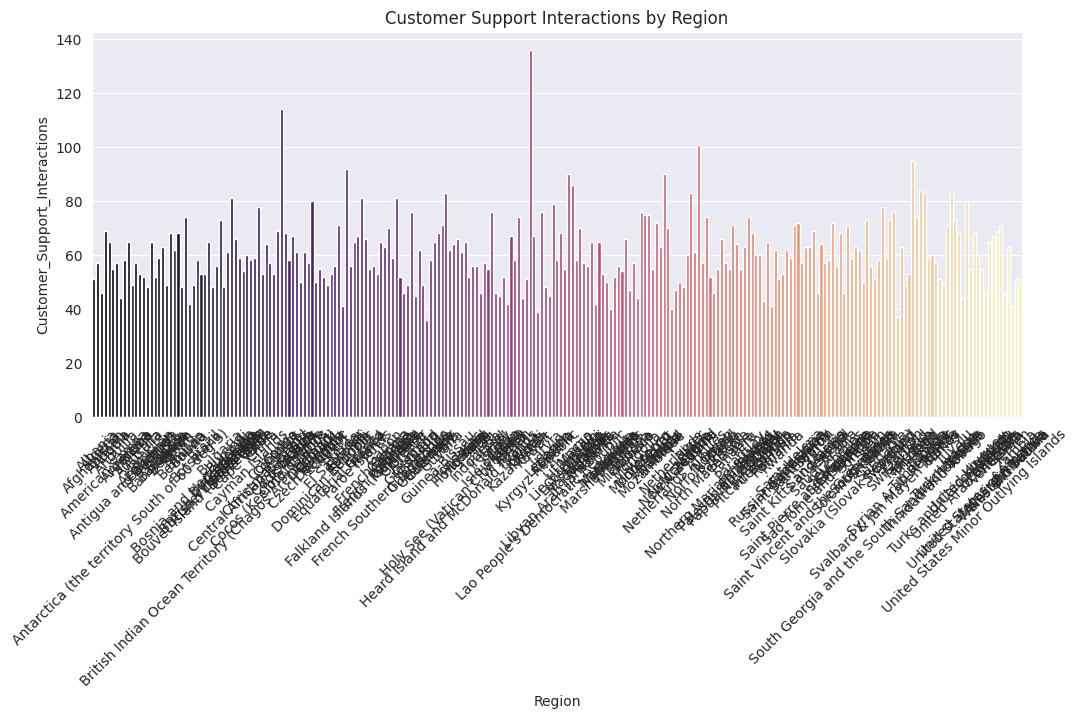

In [18]:
# 6. Heatmap: Region-wise Customer Support Interactions
plt.figure(figsize=(12, 5))
region_counts = df.groupby('Region')['Customer_Support_Interactions'].sum().reset_index()
sns.barplot(data=region_counts, x='Region', y='Customer_Support_Interactions', palette='magma')
plt.xticks(rotation=45)
plt.title("Customer Support Interactions by Region")
plt.show()

## Predictive modeling

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [20]:
# Feature selection
feature_cols = ['Active_Users', 'New_Users', 'Churned_Users', 'Input_Text_Length', 'Response_Tokens', 
                'User_Rating', 'Session_Duration_sec', 'Correction_Needed', 'User_Return_Frequency', 
                'Customer_Support_Interactions']

In [21]:
# Keep only relevant columns
feature_cols = [col for col in feature_cols if col in df.columns]
model_df = df.dropna(subset=feature_cols + ['Retention_Rate'])

In [22]:
# Define features (X) and target variable (y)
X = model_df[feature_cols]
y = model_df['Retention_Rate']

In [23]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "Support Vector Regressor": SVR(kernel='rbf'),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5)
}

In [25]:
# Store results
results = []

In [26]:
# Train & evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)  # Train the model
    y_pred = model.predict(X_test)  # Make predictions
    
    # Compute metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    # Store results
    results.append({"Model": name, "R2 Score": r2, "MAE": mae})

# Convert results to DataFrame
results_df = pd.DataFrame(results)

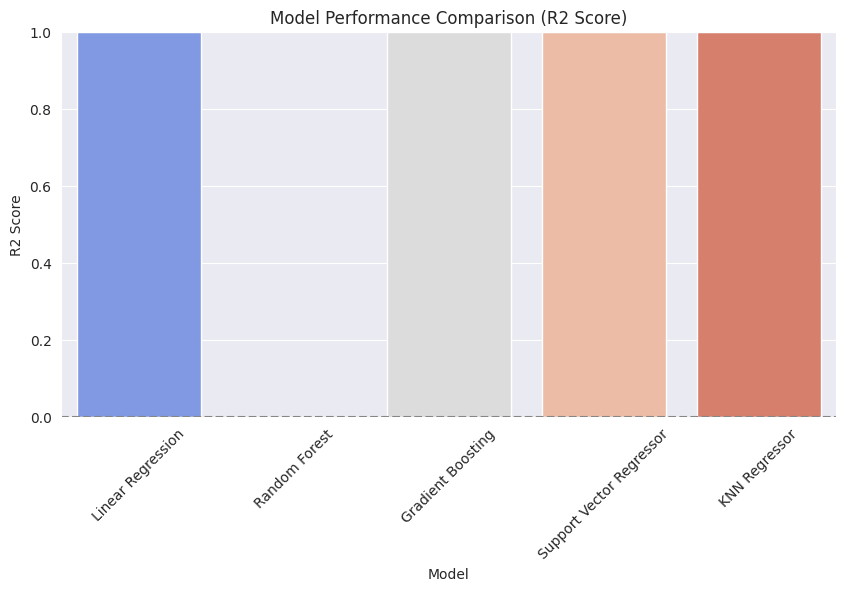

In [27]:
# Visualization: Model Comparison
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="R2 Score", palette="coolwarm")
plt.axhline(0, linestyle="--", color="gray")
plt.title("Model Performance Comparison (R2 Score)")
plt.ylim(0, 1)  # R2 Score ranges from 0 to 1
plt.xticks(rotation=45)
plt.show()

In [28]:
# Print results
print(results_df.sort_values(by="R2 Score", ascending=False))

                      Model  R2 Score           MAE
0         Linear Regression       1.0  0.000000e+00
2         Gradient Boosting       1.0  0.000000e+00
3  Support Vector Regressor       1.0  0.000000e+00
4             KNN Regressor       1.0  0.000000e+00
1             Random Forest       0.0  1.503242e-15


In [29]:
# Train & evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)  # Train the model
    y_pred = model.predict(X_test)  # Make predictions
    
    # Compute metrics
    r2 = r2_score(y_test, y_pred) * 100  # Convert to percentage
    mae = mean_absolute_error(y_test, y_pred) * 100  # Convert to percentage
    
    # Store results
    results.append({"Model": name, "R2 Score (%)": r2, "MAE (%)": mae})

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Print results in Markdown format
import markdown
markdown_text = "### Model Performance Results\n"
markdown_text += "| Model | R2 Score (%) | MAE (%) |\n|---|---|---|\n"

for index, row in results_df.iterrows():
    markdown_text += f"| {row['Model']} | {row['R2 Score (%)']:.2f}% | {row['MAE (%)']:.2f}% |\n"

print(markdown_text)  # Prints markdown table

### Model Performance Results
| Model | R2 Score (%) | MAE (%) |
|---|---|---|
| Linear Regression | nan% | nan% |
| Random Forest | nan% | nan% |
| Gradient Boosting | nan% | nan% |
| Support Vector Regressor | nan% | nan% |
| KNN Regressor | nan% | nan% |
| Linear Regression | 100.00% | 0.00% |
| Random Forest | 0.00% | 0.00% |
| Gradient Boosting | 100.00% | 0.00% |
| Support Vector Regressor | 100.00% | 0.00% |
| KNN Regressor | 100.00% | 0.00% |



## Thank you!!!....Upvote!!!!